In [1]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import plotly.express as px
import os
import sys

sys.path.insert(1, '..')
from SepsisPkg.config import SEPSIS_CONFIG

# The "Anchor" for your Rolling Window
expr_culture_orders = (
    # Look for the ORDER or PROCEDURE
    (pl.col("event_full_name").str.to_lowercase().str.contains("order")) &
    (pl.col("event_full_name").str.to_lowercase().str.contains("culture")) &
    
    # Filter for the actual REQUEST (Procedure), not the Result
    (pl.col("event_full_name").str.to_lowercase().str.contains("procedure"))
)


expr_antibiotics_gold_standard = (
    (pl.col("Event_Grouper") == "Antibiotics") & 
    
    # 1. INCLUSION: Must be a systemic route
    (pl.col("event_full_name").str.to_lowercase().str.contains(r"\biv\b|intravenous|infusion|injection|push|piggy back")) &
    
    # 2. EXCLUSION: The "Not Sepsis" Filter
    ~(pl.col("event_full_name").str.to_lowercase().str.contains(
        r"dialysis|"        # Maintenance fluids
        r"heparin|"         # Line flushes
        r"lock solution|"   # Catheter cleaning
        r"chemo|"           # Cancer treatment
        r"rubicin|"         # Specific chemo agents (Doxorubicin, etc.)
        r"epoch|"           # Chemo cocktail
        r"intravitreal|"    # Eye injections (Local)
        r"intrapleural|"    # Lung cavity (Local/Mechanical)
        r"alteplase|"       # Clot busters
        r"activase"         # Clot busters
    ))
)

def detect_sepsis_suspicion(lf: pl.LazyFrame, expr_antibiotics_gold_standard: pl.Expr,
                            expr_culture_orders: pl.Expr):
    lf_abx = lf.filter(
        expr_antibiotics_gold_standard
    ).select(
        "PAT_ENC_CSN_ID",
        pl.col("Event_DateTime").alias("ABX_Time")
    ).sort("ABX_Time")

    lf_culture = lf.filter(
        expr_culture_orders 
    ).select(
        "PAT_ENC_CSN_ID",
        pl.col("Event_DateTime").alias("culture_Time")
    ).sort("culture_Time")

    lf_suspected_backward = lf_abx.join_asof(
        lf_culture,
        left_on="ABX_Time",
        right_on="culture_Time",
        by="PAT_ENC_CSN_ID",
        strategy="backward",
        tolerance="24h"
    ).filter(pl.col("culture_Time").is_not_null())

    lf_suspected_forward = lf_abx.join_asof(
        lf_culture,
        left_on="ABX_Time",
        right_on="culture_Time",
        by="PAT_ENC_CSN_ID",
        strategy="forward",
        tolerance="72h"
    ).filter(pl.col("culture_Time").is_not_null())

    # Combine matches and pick the EARLIEST of the two times
    df_suspected_infection = (
        pl.concat([lf_suspected_backward, lf_suspected_forward])
        .unique()
        .with_columns(
            # Sepsis Time Zero = Min(Abx Time, Culture Time)
            pl.min_horizontal(["ABX_Time", "culture_Time"]).alias("Suspected_Infection_Time")
        )
        # Get the FIRST episode per encounter
        .group_by("PAT_ENC_CSN_ID")
        .agg(pl.col("Suspected_Infection_Time").min())
        .collect()
    )
    return df_suspected_infection

df_all = pl.read_parquet("../data/preprocessed_all_data.parquet")

df_suspected_infection = detect_sepsis_suspicion(
    df_all.lazy(), expr_antibiotics_gold_standard, expr_culture_orders
)
print(df_suspected_infection.shape)

(3595, 2)


sys:1: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided


In [2]:
df_all.filter((pl.col('EVENT_NAME') == "BLOOD PRESSURE")&(
    (pl.col("MEAS_VALUE").str.split('/').list.len()<2) |  pl.col("MEAS_VALUE").is_null()

    ))['MEAS_VALUE']

MEAS_VALUE
str
null
null
null
null
null
…
null
null
null


In [3]:
df_all = df_all.with_columns(
    [
        pl.when(pl.col("EVENT_NAME")=="BLOOD PRESSURE").then(
        pl.col("MEAS_VALUE").str.split("/").list.get(0, null_on_oob=True)
        ).otherwise(pl.lit(None)).cast(pl.Float64).alias('sys_bp'),
        
        pl.when(pl.col("EVENT_NAME")=="BLOOD PRESSURE").then(
        pl.col("MEAS_VALUE").str.split("/").list.get(1, null_on_oob=True)
        ).otherwise(pl.lit(None)).cast(pl.Float64).alias('dia_bp')
    ]
).with_columns(
    pl.when( (pl.col("sys_bp").is_not_null()) & (pl.col("sys_bp").is_not_nan())).then(
        (pl.col("sys_bp") + (2*pl.col("dia_bp")))/3.0
    ).alias("map")
)

The history saving thread hit an unexpected error (OperationalError('disk I/O error')).History will not be written to the database.


In [4]:
expr_clean_numeric = (
    pl.col("MEAS_VALUE")
    .str.extract(r"(-?\d+\.?\d*)", 1) # Regex to capture integer or float
    .cast(pl.Float64)
    .alias("val_numeric")
)

df_all = df_all.with_columns(
    expr_clean_numeric
)

In [5]:
expr_plat = (
    (pl.col('event_full_name').str.to_lowercase().str.contains("order result"))&
    (pl.col('event_full_name').str.to_lowercase().str.contains("platelet"))
)
df_all.filter(
    pl.col("val_numeric").is_not_null()
)

PAT_ENC_CSN_ID,PAT_MRN_ID,PAT_ID,Ethnicity,FirstRace,Sex,Coverage_Financial_Class_Grouper,Pt_Arrival,Admit_Time,DateAdmitKey,Patient_Age,Chief_Complaint_All,Before_Admit_YN,Admitted_From_ED,LOS_Days,Hours_in_ED,Event_DateTime,Type,EVENT_NAME,Event_Grouper,Result_Flag,MEAS_VALUE,Sepsis_Category,FLAG_DEATH_CLARITY,event_full_name,sys_bp,dia_bp,map,val_numeric
i64,i64,str,str,str,str,str,datetime[ns],datetime[ns],i64,f64,str,str,str,i64,i64,datetime[ns],str,str,str,str,str,str,i64,str,f64,f64,f64,f64
695960811,92882623,"""Z5340995""","""Non-Hispanic/Latino""","""Black or African American""","""Male""","""Medicare""",2024-01-06 15:26:00,2024-01-07 02:50:00,20240106,62.685831,"""BLEEDING GUMS""","""Yes""","""Yes""",393,11,2024-01-06 15:30:00,"""Flowsheet""","""WEIGHT/SCALE""","""Weight""",null,"""3840""","""NPOA-3""",0,"""Flowsheet__WEIGHT/SCALE__Weigh…",null,null,null,3840.0
695960811,92882623,"""Z5340995""","""Non-Hispanic/Latino""","""Black or African American""","""Male""","""Medicare""",2024-01-06 15:26:00,2024-01-07 02:50:00,20240106,62.685831,"""BLEEDING GUMS""","""Yes""","""Yes""",393,11,2024-01-06 15:30:00,"""Flowsheet""","""BLOOD PRESSURE""","""Blood Pressure""",null,"""105/50""","""NPOA-3""",0,"""Flowsheet__BLOOD PRESSURE__Blo…",105.0,50.0,68.333333,105.0
695960811,92882623,"""Z5340995""","""Non-Hispanic/Latino""","""Black or African American""","""Male""","""Medicare""",2024-01-06 15:26:00,2024-01-07 02:50:00,20240106,62.685831,"""BLEEDING GUMS""","""Yes""","""Yes""",393,11,2024-01-06 15:30:00,"""Flowsheet""","""RESPIRATIONS""","""Respirations""",null,"""18""","""NPOA-3""",0,"""Flowsheet__RESPIRATIONS__Respi…",null,null,null,18.0
695960811,92882623,"""Z5340995""","""Non-Hispanic/Latino""","""Black or African American""","""Male""","""Medicare""",2024-01-06 15:26:00,2024-01-07 02:50:00,20240106,62.685831,"""BLEEDING GUMS""","""Yes""","""Yes""",393,11,2024-01-06 15:30:00,"""Flowsheet""","""PULSE""","""Pulse""",null,"""76""","""NPOA-3""",0,"""Flowsheet__PULSE__Pulse""",null,null,null,76.0
695960811,92882623,"""Z5340995""","""Non-Hispanic/Latino""","""Black or African American""","""Male""","""Medicare""",2024-01-06 15:26:00,2024-01-07 02:50:00,20240106,62.685831,"""BLEEDING GUMS""","""Yes""","""Yes""",393,11,2024-01-06 15:30:00,"""Flowsheet""","""MODEL R BMI""","""BMI""",null,"""33.5""","""NPOA-3""",0,"""Flowsheet__MODEL R BMI__BMI""",null,null,null,33.5
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
739134131,98447676,"""Z10906956""","""Non-Hispanic/Latino""","""White""","""Male""","""Medicare""",2025-10-26 20:22:00,2025-10-27 02:18:00,20251026,78.707734,"""VOMITING,HYPOTENSION""","""No""","""Yes""",2,6,2025-10-28 08:16:00,"""Order Result - Microbiology""","""CULTURE""","""Body Fluid Cultures""","""Normal""","""No growth at 18-24 hours""","""POA-3""",1,"""Order Result - Microbiology__C…",null,null,null,18.0
739134131,98447676,"""Z10906956""","""Non-Hispanic/Latino""","""White""","""Male""","""Medicare""",2025-10-26 20:22:00,2025-10-27 02:18:00,20251026,78.707734,"""VOMITING,HYPOTENSION""","""No""","""Yes""",2,6,2025-10-29 07:08:00,"""Order Result - Microbiology""","""GRAM ST""","""Body Fluid Cultures""","""Abnormal""","""Aerobic And Anaerobic Bottles …","""POA-3""",1,"""Order Result - Microbiology__G…",null,null,null,24.0
739134131,98447676,"""Z10906956""","""Non-Hispanic/Latino""","""White""","""Male""","""Medicare""",2025-10-26 20:22:00,2025-10-27 02:18:00,20251026,78.707734,"""VOMITING,HYPOTENSION""","""No""","""Yes""",2,6,2025-10-29 07:08:00,"""Order Result - Microbiology""","""CULTURE""","""Body Fluid Cultures""","""Abnormal""","""Aerobic And Anaerobic Bottles …","""POA-3""",1,"""Order Result - Microbiology__C…",null,null,null,24.0


In [6]:
lf = df_all.lazy()

In [7]:
lf_labs = lf.filter(
    (pl.col("event_full_name").str.to_lowercase().str.contains("platelet|bilirubin|creatinine"))&
    (pl.col("event_full_name").str.to_lowercase().str.contains("result"))
).select(
    "PAT_ENC_CSN_ID",
    "Event_DateTime",
    "event_full_name",
    "val_numeric"
).filter(pl.col("val_numeric").is_not_null())

In [8]:
lf_labs_scored = lf_labs.with_columns(
    pl.when(pl.col("event_full_name").str.to_lowercase().str.contains("platelet"))
      .then(
          pl.when(pl.col("val_numeric") < 20).then(4)
            .when(pl.col("val_numeric") < 50).then(3)
            .when(pl.col("val_numeric") < 100).then(2)
            .when(pl.col("val_numeric") < 150).then(1)
            .otherwise(0)
      )
      .when(pl.col("event_full_name").str.to_lowercase().str.contains("bilirubin"))
      .then(
          pl.when(pl.col("val_numeric") >= 12.0).then(4)
            .when(pl.col("val_numeric") >= 6.0).then(3)
            .when(pl.col("val_numeric") >= 2.0).then(2)
            .when(pl.col("val_numeric") >= 1.2).then(1)
            .otherwise(0)
      )
      .when(pl.col("event_full_name").str.to_lowercase().str.contains("creatinine"))
      .then(
          pl.when(pl.col("val_numeric") >= 5.0).then(4)
            .when(pl.col("val_numeric") >= 3.5).then(3)
            .when(pl.col("val_numeric") >= 2.0).then(2)
            .when(pl.col("val_numeric") >= 1.2).then(1)
            .otherwise(0)
      )
      .alias("SOFA_Points")
      .cast(pl.Int32)
)

In [9]:
lf_bp = lf.filter(
    pl.col("event_full_name").str.to_lowercase().str.contains("blood pressure")
).select([
    "PAT_ENC_CSN_ID",
    "Event_DateTime",
    "sys_bp",
    "dia_bp"
]).filter(
    pl.col("sys_bp").is_not_null() & pl.col("dia_bp").is_not_null()
).with_columns(
    # Calculate Mean Arterial Pressure (MAP)
    ((pl.col("sys_bp") + (2 * pl.col("dia_bp"))) / 3).alias("val_numeric")
).with_columns(
    # Assign Score (Simple MAP < 70 check)
    # Note: Vasopressors override this score, but this is the baseline check.
    pl.when(pl.col("val_numeric") < 70).then(1).otherwise(0).alias("SOFA_Points")
)

In [10]:
vasopressor_keywords = [
    "norepinephrine", "levophed", 
    "vasopressin", "vasostrict", 
    "phenylephrine", "neo-synephrine", 
    "dopamine", 
    "epinephrine", "adrenaline",  # <--- Added this (Critical for severe shock)
    "giapreza", "angiotensin"     # <--- Added this (Newer shock drug, rare but possible)
]

expr_vasopressors_final = (
    # 1. Match ANY of the drug names
    (pl.col("event_full_name").str.to_lowercase().str.contains_any(vasopressor_keywords)) &
    
    # 2. EXCLUDE "Push Doses" (Transient use)
    # This applies your specific Phenylephrine logic to ALL pressors just to be safe
    ~(pl.col("event_full_name").str.to_lowercase().str.contains("push dose")) &
    ~(pl.col("event_full_name").str.to_lowercase().str.contains("bolus")) &
    
    # 3. EXCLUDE Specific small vial sizes (implies push dose, based on your findings)
    ~(pl.col("event_full_name").str.to_lowercase().str.contains(r"\b10 mg\b")) & 
    ~(pl.col("event_full_name").str.to_lowercase().str.contains(r"\b1 mg\b")) &
    
    # 4. EXCLUDE Diagnosis/Audit text (Keep only Orders/Admin)
    ~(pl.col("event_full_name").str.to_lowercase().str.contains("__other"))
)

In [11]:
lf_suspected = df_suspected_infection.lazy()
lf_labs_final = lf_labs_scored.select([
    "PAT_ENC_CSN_ID", "Event_DateTime", "SOFA_Points",
    pl.lit("Labs").alias("System") # Simplification: You can split into Renal/Liver/Coag
])

lf_bp_final = lf_bp.select([
    "PAT_ENC_CSN_ID", "Event_DateTime", "SOFA_Points",
    pl.lit("Cardio").alias("System")
])

lf_vaso = lf.filter(
    expr_vasopressors_final # Using the filter we built earlier
).select([
    "PAT_ENC_CSN_ID", 
    pl.col("Event_DateTime"), 
    pl.lit(3).alias("SOFA_Points"), # Vasopressor = Automatic Score 3
    pl.lit("Cardio").alias("System")
])

In [12]:
lf_sofa_all = pl.concat([
    lf_labs_final, 
    lf_bp_final, 
    lf_vaso
]).sort("Event_DateTime")

In [13]:
lf_sofa_all.collect()

PAT_ENC_CSN_ID,Event_DateTime,SOFA_Points,System
i64,datetime[ns],i32,str
695960811,2024-01-06 15:30:00,1,"""Cardio"""
695960811,2024-01-06 17:30:00,1,"""Labs"""
695960811,2024-01-06 17:30:00,0,"""Labs"""
695960811,2024-01-06 17:41:00,0,"""Cardio"""
695960811,2024-01-06 18:22:00,4,"""Labs"""
…,…,…,…
699476058,2025-10-31 05:00:00,1,"""Cardio"""
699476058,2025-10-31 05:30:00,1,"""Cardio"""
699476058,2025-10-31 06:00:00,1,"""Cardio"""


In [14]:
lf_window_analysis = (
    lf_suspected.join(
        lf_sofa_all, 
        on="PAT_ENC_CSN_ID", 
        how="inner" 
    )
    .filter(
        # Filter for events inside the Sepsis-3 Window
        (pl.col("Event_DateTime") >= pl.col("Suspected_Infection_Time") - pl.duration(hours=48)) &
        (pl.col("Event_DateTime") <= pl.col("Suspected_Infection_Time") + pl.duration(hours=24))
    )
)

In [15]:
df_confirmed_sepsis = (
    lf_window_analysis
    .group_by(["PAT_ENC_CSN_ID", "System"])
    .agg(pl.col("SOFA_Points").max().alias("Max_System_Score")) # Worst score per organ
    .group_by("PAT_ENC_CSN_ID")
    .agg(pl.col("Max_System_Score").sum().alias("Total_SOFA_Score")) # Sum organs
    .filter(pl.col("Total_SOFA_Score") >= 2) # THE SEPSIS THRESHOLD
    .collect()
)

print(f"Suspected Infection Episodes: {df_suspected_infection.height}")
print(f"Confirmed Sepsis Episodes (SOFA >= 2): {df_confirmed_sepsis.height}")

Suspected Infection Episodes: 3595
Confirmed Sepsis Episodes (SOFA >= 2): 2195


In [16]:
##############################################################################################################
# All encounters cell (1/2) Run either this or the following one
##############################################################################################################

df_viz = df_suspected_infection.join(
    df_all.select(["PAT_ENC_CSN_ID", "Pt_Arrival", "Admitted_From_ED", "FLAG_DEATH_CLARITY"]).unique(),
    on="PAT_ENC_CSN_ID",
    how="left"
).with_columns(
    # Calculate Hours elapsed from Arrival to Action
    ((pl.col("Suspected_Infection_Time") - pl.col("Pt_Arrival")).dt.total_hours()).alias("Hours_to_Action"),
    
    # Create a Label for Death (Alive vs Expired)
    pl.when(pl.col("FLAG_DEATH_CLARITY") == 1).then(pl.lit("Deceased"))
      .otherwise(pl.lit("Alive")).alias("Outcome")
)

# Filter for reasonable outliers (e.g., exclude negative times or > 1000 hours)
# We focus on the first 48 hours for the most impact
df_plot = df_viz.filter(
    (pl.col("Hours_to_Action") >= 0) & 
    (pl.col("Hours_to_Action") <= 48)
).to_pandas() # Convert to Pandas for Plotly

In [27]:
##############################################################################################################
# Only NPOA- Encounters cell (2/2)
##############################################################################################################
df_viz = df_suspected_infection.join(
    df_all.select(["PAT_ENC_CSN_ID", "Pt_Arrival", "Admitted_From_ED", "FLAG_DEATH_CLARITY", "Sepsis_Category"]).unique(),
    on="PAT_ENC_CSN_ID",
    how="left"
).filter(pl.col("Sepsis_Category").str.contains("NPOA-")).with_columns(
    # Calculate Hours elapsed from Arrival to Action
    ((pl.col("Suspected_Infection_Time") - pl.col("Pt_Arrival")).dt.total_hours()).alias("Hours_to_Action"),
    
    # Create a Label for Death (Alive vs Expired)
    pl.when(pl.col("FLAG_DEATH_CLARITY") == 1).then(pl.lit("Deceased"))
      .otherwise(pl.lit("Alive")).alias("Outcome")
)

# Filter for reasonable outliers (e.g., exclude negative times or > 1000 hours)
# We focus on the first 48 hours for the most impact
df_plot = df_viz.filter(
    (pl.col("Hours_to_Action") >= 0) & 
    (pl.col("Hours_to_Action") <= 48)
).to_pandas() # Convert to Pandas for Plotly

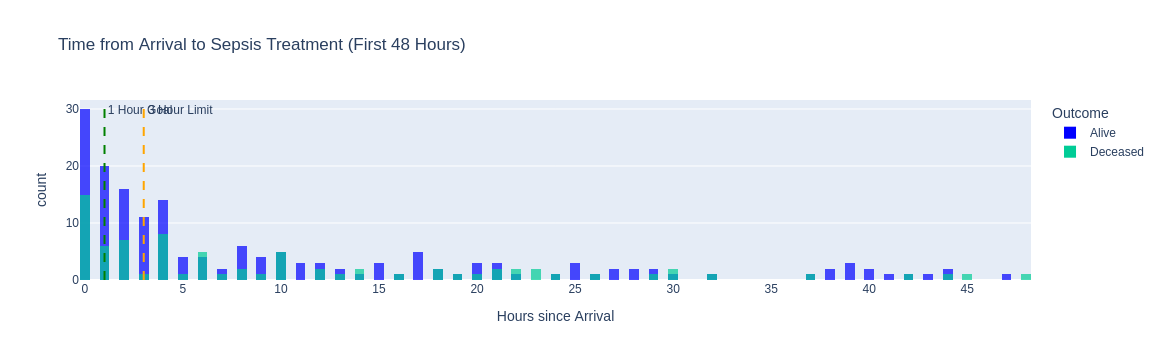

In [28]:
# Create Histogram
fig_hist = px.histogram(
    df_plot, 
    x="Hours_to_Action", 
    nbins=128, # One bin per hour
    color="Outcome", # Color by Survival to see if delays kill
    title="Time from Arrival to Sepsis Treatment (First 48 Hours)",
    labels={"Hours_to_Action": "Hours since Arrival", "count": "Number of Patients"},
    barmode="overlay",
    opacity=0.7,
    color_discrete_map={"Alive": "blue", "Expired": "red"}
)

# Add "Goal" Lines (SEP-1 Guidelines)
fig_hist.add_vline(x=1, line_dash="dash", line_color="green", annotation_text="1 Hour Goal")
fig_hist.add_vline(x=3, line_dash="dash", line_color="orange", annotation_text="3 Hour Limit")

fig_hist.show()

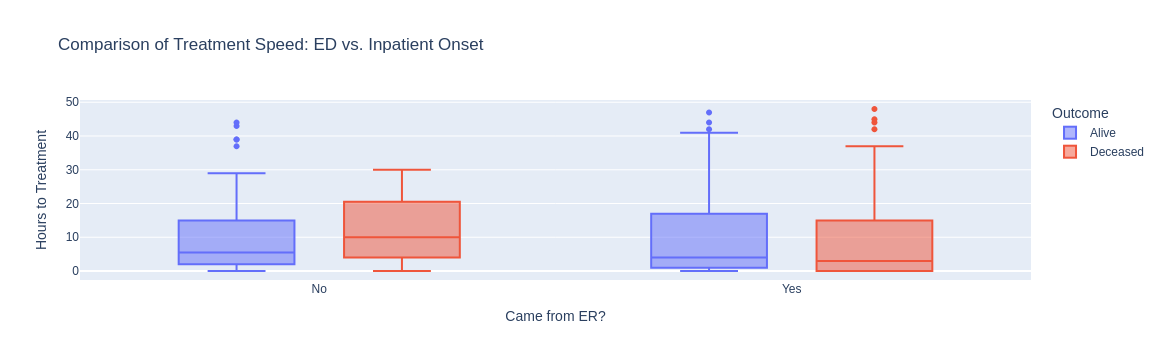

In [29]:
fig_box = px.box(
    df_plot, 
    x="Admitted_From_ED", 
    y="Hours_to_Action", 
    color="Outcome",
    title="Comparison of Treatment Speed: ED vs. Inpatient Onset",
    labels={"Admitted_From_ED": "Came from ER?", "Hours_to_Action": "Hours to Treatment"},
    points="outliers" # Only show outliers as dots
)

fig_box.show()

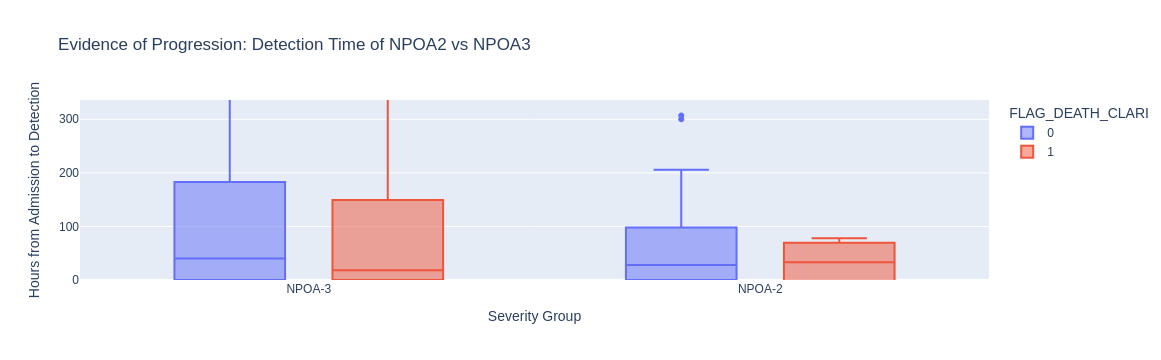

Mortality & Frequency by Category:
shape: (8, 5)
┌─────────────────┬───────┬────────┬─────────────┬───────────────────────────┐
│ Sepsis_Category ┆ Count ┆ Deaths ┆ Mortality_% ┆ Median_Hours_to_Detection │
│ ---             ┆ ---   ┆ ---    ┆ ---         ┆ ---                       │
│ str             ┆ u64   ┆ i64    ┆ f64         ┆ f64                       │
╞═════════════════╪═══════╪════════╪═════════════╪═══════════════════════════╡
│ NPOA-1          ┆ 192   ┆ 13     ┆ 6.8         ┆ 60.0                      │
│ NPOA-2          ┆ 46    ┆ 8      ┆ 17.4        ┆ 28.0                      │
│ NPOA-3          ┆ 300   ┆ 129    ┆ 43.0        ┆ 34.0                      │
│ POA-1           ┆ 1597  ┆ 31     ┆ 1.9         ┆ -8.0                      │
│ POA-2           ┆ 660   ┆ 20     ┆ 3.0         ┆ -8.0                      │
│ POA-3           ┆ 734   ┆ 200    ┆ 27.2        ┆ -4.0                      │
│ UPOA-1          ┆ 60    ┆ 1      ┆ 1.7         ┆ -8.0                      │
│ U

/tmp/ipykernel_2929590/1661984488.py:65: DeprecationWarning:

`pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)



In [30]:
import polars as pl
import plotly.express as px

# -------------------------------------------------------------------------
# 1. PARSE THE SEPSIS CATEGORY
# -------------------------------------------------------------------------
# We extract "POA/NPOA" and the "Severity Level" (1, 2, 3)
df_coded = df_all.select([
    "PAT_ENC_CSN_ID", "Sepsis_Category", "Admit_Time", "FLAG_DEATH_CLARITY"
]).unique().with_columns(
    # Extract Type (POA vs NPOA)
    pl.col("Sepsis_Category").str.extract(r"([A-Z]+)", 1).alias("Onset_Type"),
    
    # Extract Severity (1, 2, 3)
    pl.col("Sepsis_Category").str.extract(r"(\d+)", 1).cast(pl.Int32).alias("Severity_Level")
)

# -------------------------------------------------------------------------
# 2. JOIN WITH CLINICAL TIME ZERO
# -------------------------------------------------------------------------
# We compare the "Billing Code" (Sepsis_Category) vs "Clinical Reality" (Time Zero)
df_comparison = df_coded.join(
    df_suspected_infection, # From previous steps
    on="PAT_ENC_CSN_ID",
    how="inner"
).with_columns(
    # METRIC: How many hours into the hospitalization did we catch it?
    ((pl.col("Suspected_Infection_Time") - pl.col("Admit_Time")).dt.total_hours()).alias("Hours_from_Admit_to_Suspicion")
)

# Filter for the "Problem Group" (Hospital Acquired - NPOA)
df_npoa = df_comparison.filter(
    (pl.col("Onset_Type") == "NPOA") & 
    (pl.col("Severity_Level").is_in([2, 3]))
).to_pandas()

# -------------------------------------------------------------------------
# 3. VISUALIZATION A: THE "PROGRESSION DELAY" BOX PLOT
# -------------------------------------------------------------------------
# This answers: "Are NPOA3 patients found LATER than NPOA2?"
fig_box = px.box(
    df_npoa, 
    x="Sepsis_Category", # NPOA2 vs NPOA3
    y="Hours_from_Admit_to_Suspicion",
    color="FLAG_DEATH_CLARITY", # Check if late detection = Death
    title="Evidence of Progression: Detection Time of NPOA2 vs NPOA3",
    labels={
        "Hours_from_Admit_to_Suspicion": "Hours from Admission to Detection", 
        "Sepsis_Category": "Severity Group"
    },
    category_orders={"Sepsis_Category": ["NPOA2", "NPOA3"]} # Force order
)
# Zoom in on the first 2 weeks (336 hours) to see the detail, ignoring super-long outliers
fig_box.update_yaxes(range=[0, 336]) 
fig_box.show()

# -------------------------------------------------------------------------
# 4. VISUALIZATION B: THE MORTALITY TABLE
# -------------------------------------------------------------------------
# This confirms if NPOA3 is indeed more lethal (as expected)
print("Mortality & Frequency by Category:")
print(
    df_comparison.group_by("Sepsis_Category")
    .agg([
        pl.count().alias("Count"),
        pl.col("FLAG_DEATH_CLARITY").sum().alias("Deaths"),
        (pl.col("FLAG_DEATH_CLARITY").mean() * 100).round(1).alias("Mortality_%"),
        pl.col("Hours_from_Admit_to_Suspicion").median().round(1).alias("Median_Hours_to_Detection")
    ])
    .sort("Sepsis_Category")
)

In [31]:
import polars as pl
import plotly.express as px

# 1. SETUP: We need the full SOFA stream and the Suspicion list
# Assuming 'lf_sofa_all' contains all scored labs/vitals
# Assuming 'df_suspected_infection' contains the time the doctor acted
lf = df_all.lazy()
lf_suspected = df_suspected_infection.lazy()

# -------------------------------------------------------------------------
# STEP A: CALCULATE TOTAL SOFA AT EVERY TIMESTAMP
# -------------------------------------------------------------------------
# We need a rolling total of the SOFA score.
# This requires aggregating by Timepoint (e.g., hourly or per event).
# For simplicity/speed, we check if ANY single system failed prior to suspicion.

# Filter SOFA events occurring BEFORE Suspicion (The "Look-Back")
lf_onset_check = (
    lf_suspected.join(
        lf_sofa_all, # Your Combined Scored Vitals (Labs + BP + Vaso)
        on="PAT_ENC_CSN_ID",
        how="inner"
    )
    .filter(
        # Look at the 48 hours BEFORE the doctor acted
        (pl.col("Event_DateTime") >= pl.col("Suspected_Infection_Time") - pl.duration(hours=48)) &
        (pl.col("Event_DateTime") < pl.col("Suspected_Infection_Time")) &
        
        # Filter for Critical Events (Score >= 1 point for that system)
        # Note: Strictly Sepsis is Total >= 2, but finding the FIRST organ dysfunction (>=1) 
        # is a sharper proxy for "When did the crash start?"
        (pl.col("SOFA_Points") >= 2)
    )
)

# -------------------------------------------------------------------------
# STEP B: DETERMINE "PHYSIOLOGICAL ONSET"
# -------------------------------------------------------------------------
df_onset_gap = (
    lf_onset_check
    .group_by("PAT_ENC_CSN_ID")
    .agg([
        pl.col("Suspected_Infection_Time").first(),
        
        # The earliest sign of organ failure
        pl.col("Event_DateTime").min().alias("Physiological_Onset_Time"),
        
        # What failed first? (e.g., "Cardio" or "Renal")
        pl.col("System").sort_by("Event_DateTime").first().alias("First_Organ_Failed")
    ])
    .with_columns(
        # THE GAP: How long did the patient wait?
        ((pl.col("Suspected_Infection_Time") - pl.col("Physiological_Onset_Time"))
         .dt.total_hours())
         .alias("Hours_Lag_Organ_Failure_to_Action")
    )
    .collect()
)

# -------------------------------------------------------------------------
# STEP C: JOIN WITH SEPSIS CATEGORY (NPOA2 vs NPOA3)
# -------------------------------------------------------------------------
# We define df_coded in the previous turn (extracting POA/NPOA)
df_gap_analysis = df_onset_gap.join(
    df_coded, # Contains "Sepsis_Category", "Onset_Type", "Severity_Level"
    on="PAT_ENC_CSN_ID",
    how="inner"
).to_pandas()

# Filter for Hospital Acquired (NPOA) to test your hypothesis
df_npoa_gap = df_gap_analysis[
    df_gap_analysis["Onset_Type"] == "NPOA"
]

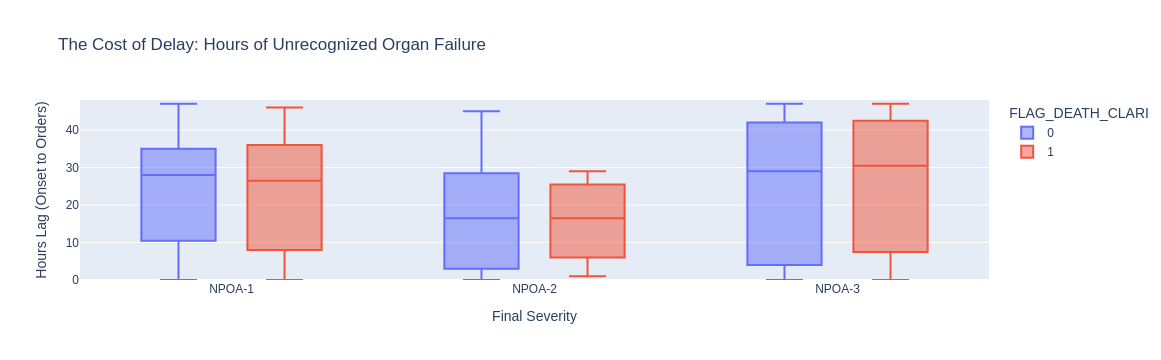

In [21]:
fig_lag = px.box(
    df_npoa_gap, 
    x="Sepsis_Category", # NPOA2 vs NPOA3
    y="Hours_Lag_Organ_Failure_to_Action",
    color="FLAG_DEATH_CLARITY",
    title="The Cost of Delay: Hours of Unrecognized Organ Failure",
    labels={
        "Hours_Lag_Organ_Failure_to_Action": "Hours Lag (Onset to Orders)", 
        "Sepsis_Category": "Final Severity"
    },
    category_orders={"Sepsis_Category": ["NPOA-1", "NPOA-2", "NPOA-3"]}
)
fig_lag.update_yaxes(range=[0, 48]) # Focus on the 48h lookback window
fig_lag.show()

# Conclusion
1) NPOA-3 takes longer time to be detected that NPOA-2 which confirms the hypothesis that sepsis is missed in earlier cases<br>
"We have identified a specific window of missed opportunity. Our data shows that 'Moderate' sepsis (NPOA-2) is detected with a median lag of 16 hours. However, 'Severe' sepsis (NPOA-3) has a median lag of 30 hours. This 14-hour delay strongly suggests that NPOA-3 is not a baseline state, but a consequence of failure to rescue NPOA-2 patients in time.
# Questions
1) What kind of failures takes the longest time to detect?
2) What are the diagnosis, Chief Complaint, and demographics of the patients who takes significantly longer to detect their sepsis? Are they unique?
3) 

Lag Time by First Organ Failure:
  First_Organ_Failed  Count  Median_Lag_Hours  Mean_Lag_Hours
0               Labs    182              28.0       26.054945
1             Cardio     37               4.0       18.027027


/tmp/ipykernel_2929590/1557081234.py:10: DeprecationWarning:

`pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)



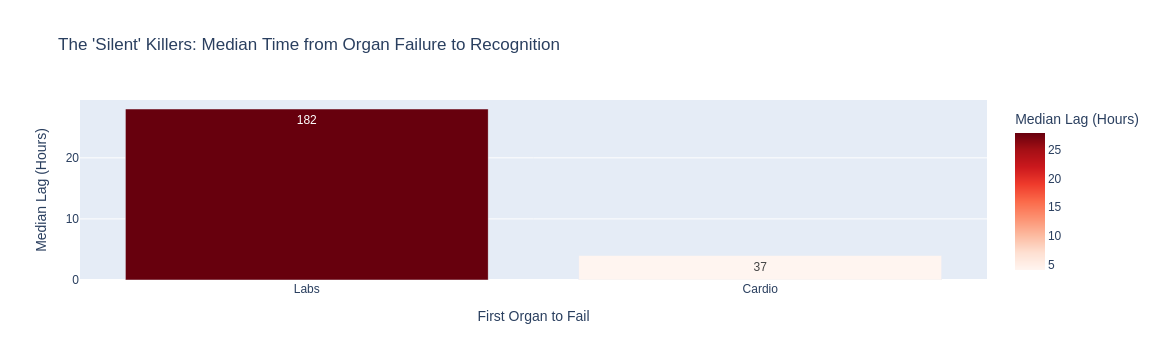

In [22]:
import polars as pl
import plotly.express as px

# 1. AGGREGATE LAG TIME BY ORGAN SYSTEM
# We look at Median Lag because outliers (extreme delays) skew the mean.
df_silent_failure = (
    pl.from_pandas(df_npoa_gap)
    .group_by("First_Organ_Failed")
    .agg([
        pl.count().alias("Count"),
        pl.col("Hours_Lag_Organ_Failure_to_Action").median().alias("Median_Lag_Hours"),
        pl.col("Hours_Lag_Organ_Failure_to_Action").mean().alias("Mean_Lag_Hours")
    ])
    .sort("Median_Lag_Hours", descending=True)
    .to_pandas()
)

# 2. VISUALIZE THE "HIERARCHY OF SILENCE"
print("Lag Time by First Organ Failure:")
print(df_silent_failure)

fig_organ_lag = px.bar(
    df_silent_failure,
    x="First_Organ_Failed",
    y="Median_Lag_Hours",
    color="Median_Lag_Hours",
    text="Count", # Show how many patients had this failure
    title="The 'Silent' Killers: Median Time from Organ Failure to Recognition",
    labels={"Median_Lag_Hours": "Median Lag (Hours)", "First_Organ_Failed": "First Organ to Fail"},
    color_continuous_scale="Reds"
)
fig_organ_lag.show()

# Conclusion
"Our NPOA-3 problem is driven by 'Silent' organ dysfunction. When a patient's first sign of sepsis is Hypotension (Cardio), we catch it in 4 hours. When the first sign is Renal or Coagulation failure (Labs), we miss it for 28 hours. This 24-hour blind spot allows 'Silent' sepsis to progress into Severe sepsis before we ever intervene."

In [23]:
type(df_gap_analysis)

pandas.core.frame.DataFrame

In [24]:
# 1. DEFINE THE COHORTS
# We start with the Gap Analysis dataframe and join back demographics
df_cohorts = pl.from_pandas(df_gap_analysis).join(
    df_all.select(["PAT_ENC_CSN_ID", "Patient_Age", "Chief_Complaint_All", "Sex"]).unique(),
    on="PAT_ENC_CSN_ID",
    how="left"
).with_columns(
    pl.when(pl.col("Hours_Lag_Organ_Failure_to_Action") >= 20).then(pl.lit("Delayed (>20h)"))
      .when(pl.col("Hours_Lag_Organ_Failure_to_Action") <= 3).then(pl.lit("Timely (<3h)"))
      .otherwise(pl.lit("Average"))
      .alias("Detection_Speed")
)

# 2. FILTER FOR THE RELEVANT GROUPS
df_delayed_profile = df_cohorts.filter(
    pl.col("Detection_Speed").is_in(["Delayed (>20h)", "Timely (<3h)"])
)

# 3. ANALYZE CHIEF COMPLAINTS (The "Trojan Horse" Check)
# Clean the text to group "Abd Pain" and "Abdominal Pain" together
df_complaints = (
    df_delayed_profile.with_columns(
        pl.col("Chief_Complaint_All")
        .str.to_lowercase()
        .str.replace_all(r"[^\w\s]", "") # Remove punctuation
        .alias("Clean_Complaint")
    )
    .group_by(["Detection_Speed", "Clean_Complaint"])
    .count()
    .sort("count", descending=True)
    .group_by("Detection_Speed")
    .head(10) # Get Top 10 for each group
    .sort(["Detection_Speed", "count"], descending=[False, True])
)

print("Top 10 Chief Complaints by Detection Speed:")
print(df_complaints.to_pandas())

# 4. ANALYZE DEMOGRAPHICS (Age/Sex)
print("\nDemographics by Detection Speed:")
print(
    df_delayed_profile.group_by("Detection_Speed").agg([
        pl.col("Patient_Age").mean().alias("Avg_Age"),
        pl.col("Patient_Age").median().alias("Median_Age"),
        (pl.col("Sex") == "Male").mean().alias("Male_%") # Check if gender bias exists
    ])
)

Top 10 Chief Complaints by Detection Speed:
   Detection_Speed        Clean_Complaint  count
0   Delayed (>20h)                   None     83
1   Delayed (>20h)      breathing problem     17
2   Delayed (>20h)             chest pain     13
3   Delayed (>20h)         abdominal pain     12
4   Delayed (>20h)         abnormal tests     10
5   Delayed (>20h)                   pain      8
6   Delayed (>20h)  altered mental status      5
7   Delayed (>20h)                  falls      4
8   Delayed (>20h)   generalized weakness      4
9   Delayed (>20h)            sob at rest      4
10    Timely (<3h)                   None     80
11    Timely (<3h)      breathing problem     22
12    Timely (<3h)         abdominal pain     18
13    Timely (<3h)   generalized weakness     12
14    Timely (<3h)                  fever      9
15    Timely (<3h)                  other      9
16    Timely (<3h)                  falls      8
17    Timely (<3h)             chest pain      7
18    Timely (<3h)       

/tmp/ipykernel_2929590/1399393467.py:29: DeprecationWarning:

`GroupBy.count` was renamed; use `GroupBy.len` instead



/tmp/ipykernel_2929590/1208611825.py:88: DeprecationWarning:

`GroupBy.count` was renamed; use `GroupBy.len` instead



   Detection_Speed Complaint_Group          Presentation_Pattern  count  \
0   Delayed (>20h)        Abd Pain           Afebrile (No Fever)      5   
1   Delayed (>20h)        Abd Pain  Silent Crash (Failure First)      6   
2   Delayed (>20h)        Abd Pain    Warning Shot (Fever First)      5   
3     Timely (<3h)        Abd Pain           Afebrile (No Fever)     17   
4     Timely (<3h)        Abd Pain  Silent Crash (Failure First)     10   
5     Timely (<3h)        Abd Pain    Warning Shot (Fever First)      2   
6   Delayed (>20h)  Breathing/Resp           Afebrile (No Fever)     11   
7   Delayed (>20h)  Breathing/Resp  Silent Crash (Failure First)      6   
8   Delayed (>20h)  Breathing/Resp    Warning Shot (Fever First)      3   
9     Timely (<3h)  Breathing/Resp           Afebrile (No Fever)     16   
10    Timely (<3h)  Breathing/Resp  Silent Crash (Failure First)      8   
11  Delayed (>20h)      Chest Pain           Afebrile (No Fever)      3   
12  Delayed (>20h)      C

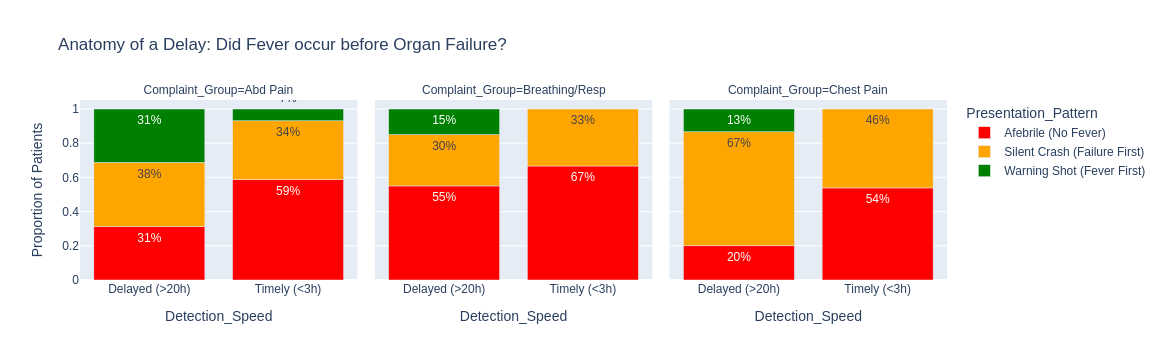

In [25]:
import polars as pl
import plotly.express as px

# 1. SETUP: LOAD DATA
lf = df_all.lazy()
# We assume 'df_gap_analysis' (from previous step) has 'Physiological_Onset_Time'
# and the "Delayed/Timely" labels.

# -------------------------------------------------------------------------
# STEP A: EXTRACT FIRST FEVER TIME
# -------------------------------------------------------------------------
# We need to clean the temperature column and find the first spike.
lf_fever = (
    lf.filter(
        (pl.col("event_full_name").str.to_lowercase().str.contains("temperature")) &
        (pl.col("MEAS_VALUE").is_not_null())
    )
    .with_columns(
        # Extract number
        pl.col("MEAS_VALUE").str.extract(r"(\d+\.?\d*)", 1).cast(pl.Float64).alias("Temp_Value")
    )
    .filter(
        # Define Fever Threshold (Handle Celsius and Fahrenheit)
        # > 38.0 C  OR  > 100.4 F
        (pl.col("Temp_Value") > 38.0) & (pl.col("Temp_Value") < 45.0) | 
        (pl.col("Temp_Value") > 100.4)
    )
    .group_by("PAT_ENC_CSN_ID")
    .agg(pl.col("Event_DateTime").min().alias("First_Fever_Time"))
)

# -------------------------------------------------------------------------
# STEP B: FILTER FOR TARGET COMPLAINTS
# -------------------------------------------------------------------------
# We only want to look at the specific complaints you mentioned.
target_complaints = ["chest pain", "abdominal pain", "breathing", "shortness of breath", "dyspnea"]

# Prepare the Main Cohort (Delayed/Timely) with Complaints
df_cohort_complaints = pl.from_pandas(df_gap_analysis).join(
    df_all.select(["PAT_ENC_CSN_ID", "Chief_Complaint_All"]).unique(),
    on="PAT_ENC_CSN_ID",
    how="left"
).with_columns(
    # Clean and Label the Complaint
    pl.col("Chief_Complaint_All").str.to_lowercase().alias("clean_cc")
).filter(
    # Filter for your specific interest areas
    pl.col("clean_cc").str.contains_any(target_complaints)
).with_columns(
    # Group them for cleaner plotting
    pl.when(pl.col("clean_cc").str.contains("chest")).then(pl.lit("Chest Pain"))
      .when(pl.col("clean_cc").str.contains("abdom")).then(pl.lit("Abd Pain"))
      .otherwise(pl.lit("Breathing/Resp")).alias("Complaint_Group"),
      
    # Re-apply the Speed Labels
    pl.when(pl.col("Hours_Lag_Organ_Failure_to_Action") >= 20).then(pl.lit("Delayed (>20h)"))
      .when(pl.col("Hours_Lag_Organ_Failure_to_Action") <= 3).then(pl.lit("Timely (<3h)"))
      .otherwise(pl.lit("Average"))
      .alias("Detection_Speed")
).filter(
    pl.col("Detection_Speed").is_in(["Delayed (>20h)", "Timely (<3h)"])
)

# -------------------------------------------------------------------------
# STEP C: DETERMINE THE SEQUENCE (FEVER vs FAILURE)
# -------------------------------------------------------------------------
df_sequence = (
    df_cohort_complaints.lazy()
    .join(lf_fever, on="PAT_ENC_CSN_ID", how="left")
    .with_columns(
        # Calculate the Sequence
        pl.when(pl.col("First_Fever_Time").is_null())
          .then(pl.lit("Afebrile (No Fever)"))
          .when(pl.col("First_Fever_Time") < pl.col("Physiological_Onset_Time"))
          .then(pl.lit("Warning Shot (Fever First)"))
          .otherwise(pl.lit("Silent Crash (Failure First)"))
          .alias("Presentation_Pattern")
    )
    .collect()
)

# -------------------------------------------------------------------------
# STEP D: VISUALIZE THE DIFFERENCE
# -------------------------------------------------------------------------
# We count the patterns per group
df_plot = (
    df_sequence.group_by(["Detection_Speed", "Complaint_Group", "Presentation_Pattern"])
    .count()
    .with_columns(
        # Calculate Percentage within each Complaint/Speed group
        (pl.col("count") / pl.col("count").sum().over(["Detection_Speed", "Complaint_Group"]))
        .alias("Percentage")
    )
    .sort(["Complaint_Group", "Detection_Speed", "Presentation_Pattern"])
    .to_pandas()
)

print(df_plot)

# Create the Stacked Bar Chart
fig_seq = px.bar(
    df_plot,
    x="Detection_Speed",
    y="Percentage",
    color="Presentation_Pattern",
    facet_col="Complaint_Group", # Separate charts for Chest, Abd, Breathing
    title="Anatomy of a Delay: Did Fever occur before Organ Failure?",
    labels={"Percentage": "Proportion of Patients"},
    color_discrete_map={
        "Warning Shot (Fever First)": "green",
        "Silent Crash (Failure First)": "orange",
        "Afebrile (No Fever)": "red"
    },
    text_auto=".0%"
)
fig_seq.show()

In [26]:
# -------------------------------------------------------------------------
# 1. SETUP: PREPARE THE DELAYED NPOA COHORT
# -------------------------------------------------------------------------
# We assume 'df_gap_analysis' is available from the previous "Gap Analysis" step.
# It must contain: 'PAT_ENC_CSN_ID', 'Hours_Lag_Organ_Failure_to_Action', 
# 'Physiological_Onset_Time', 'Sepsis_Category', 'Chief_Complaint_All'

target_complaints = ["chest pain", "abdominal pain", "breathing", "shortness of breath", "dyspnea"]

# Filter for the specific group we want to analyze
df_delayed_npoa = pl.from_pandas(df_gap_analysis).filter(
    (pl.col("Hours_Lag_Organ_Failure_to_Action") >= 20) &       # The Delayed Group
    (pl.col("Sepsis_Category").str.contains("NPOA")) &           # Hospital Acquired
    (pl.col("Chief_Complaint_All").str.to_lowercase().str.contains_any(target_complaints))
).with_columns(
    # Create Clean Complaint Groups
    pl.col("Chief_Complaint_All").str.to_lowercase().alias("clean_cc")
).with_columns(
    pl.when(pl.col("clean_cc").str.contains("chest")).then(pl.lit("Chest Pain"))
      .when(pl.col("clean_cc").str.contains("abdom")).then(pl.lit("Abd Pain"))
      .otherwise(pl.lit("Breathing/Resp")).alias("Complaint_Group")
)

# -------------------------------------------------------------------------
# 2. FIND FIRST FEVER TIME (Lazy Evaluation)
# -------------------------------------------------------------------------
lf_fever_check = (
    df_all.lazy().filter(
        (pl.col("event_full_name").str.to_lowercase().str.contains("temperature")) &
        (pl.col("MEAS_VALUE").is_not_null())
    )
    .with_columns(
        # Extract number from string like "38.5 C"
        pl.col("MEAS_VALUE").str.extract(r"(\d+\.?\d*)", 1).cast(pl.Float64).alias("Temp_Value")
    )
    .filter(
        # Fever Threshold: > 38.0 C or > 100.4 F
        (pl.col("Temp_Value") > 38.0) & (pl.col("Temp_Value") < 45.0) | 
        (pl.col("Temp_Value") > 100.4)
    )
    .group_by("PAT_ENC_CSN_ID")
    .agg(pl.col("Event_DateTime").min().alias("First_Fever_Time"))
)

# -------------------------------------------------------------------------
# 3. DETERMINE PRESENTATION PATTERN (The "Timeline" Check)
# -------------------------------------------------------------------------
df_sequence_split = (
    df_delayed_npoa
    .join(lf_fever_check, on="PAT_ENC_CSN_ID", how="left")
    .with_columns(
        pl.when(pl.col("First_Fever_Time").is_null())
          .then(pl.lit("Afebrile (No Fever)"))
          .when(pl.col("First_Fever_Time") < pl.col("Physiological_Onset_Time"))
          .then(pl.lit("Warning Shot (Fever First)"))
          .otherwise(pl.lit("Silent Crash (Failure First)"))
          .alias("Presentation_Pattern")
    )
    # .collect()
)

# -------------------------------------------------------------------------
# 4. AGGREGATE & VISUALIZE
# -------------------------------------------------------------------------
# Calculate percentages within each Sepsis Category
df_plot_split = (
    df_sequence_split.group_by(["Sepsis_Category", "Complaint_Group", "Presentation_Pattern"])
    .count()
    .with_columns(
        (pl.col("count") / pl.col("count").sum().over(["Sepsis_Category", "Complaint_Group"]))
        .alias("Percentage")
    )
    .sort(["Complaint_Group", "Sepsis_Category", "Presentation_Pattern"]).collect()
    .to_pandas()
)

print(df_plot_split)

# Generate the Faceted Bar Chart
fig_split = px.bar(
    df_plot_split,
    x="Sepsis_Category",  # Compares NPOA1 vs NPOA2 vs NPOA3
    y="Percentage",
    color="Presentation_Pattern",
    facet_col="Complaint_Group", # Separate panels for Chest vs Abd vs Breathing
    title="The Delayed Cohort (>20h): Presentation Patterns by Severity",
    labels={"Percentage": "Proportion of Patients"},
    color_discrete_map={
        "Warning Shot (Fever First)": "green",
        "Silent Crash (Failure First)": "orange",
        "Afebrile (No Fever)": "red"
    },
    text_auto=".0%",
    category_orders={
        "Sepsis_Category": ["NPOA1", "NPOA2", "NPOA3"],
        "Presentation_Pattern": ["Warning Shot (Fever First)", "Silent Crash (Failure First)", "Afebrile (No Fever)"]
    }
)

fig_split.show()

ColumnNotFoundError: unable to find column "Chief_Complaint_All"; valid columns: ["PAT_ENC_CSN_ID", "Suspected_Infection_Time", "Physiological_Onset_Time", "First_Organ_Failed", "Hours_Lag_Organ_Failure_to_Action", "Sepsis_Category", "Admit_Time", "FLAG_DEATH_CLARITY", "Onset_Type", "Severity_Level"]

In [ ]:
df_delayed_npoa

In [ ]:
df_delayed_npoa